# 02. Dynamic Causal Analysis & Difference-in-Differences

This notebook evaluates the causal impact of the horror competitor launch using:
1. **Parallel Trends Validation**: Statistical check across pre-period Weeks 1–52.
2. **Weighted Dynamic DiD Regression**: Binned lag block specification to measure phase impact without collinearity artifacts.
3. **Point-to-Point Hypothesis Test**: Formal test evaluating the difference between peak shock (Weeks 57–60) and settled tail (Weeks 67–78).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

# Load aggregated panel
df_agg = pd.read_csv('../data/processed/did_weekly_aggregated.csv')

# Assign Binned Time Windows to model post-launch dynamics cleanly
def assign_time_window(week):
    if week <= 52:
        return '0_Pre_Launch'
    elif week <= 56:
        return '1_Initial_Trial (W53-56)'
    elif week <= 60:
        return '2_Peak_Shock (W57-60)'
    elif week <= 66:
        return '3_Early_Decay (W61-66)'
    else:
        return '4_Settled_Tail (W67-78)'

df_agg['time_window'] = df_agg['week'].apply(assign_time_window)
df_agg.head()

,genre_group,week,treated,post_launch,churned,sub_count,time_window
0,Horror,1,1,0,0.008438,80000,0_Pre_Launch
1,Horror,2,1,0,0.007938,80000,0_Pre_Launch
2,Horror,3,1,0,0.007213,80000,0_Pre_Launch
3,Horror,4,1,0,0.008100,80000,0_Pre_Launch
4,Horror,5,1,0,0.008613,80000,0_Pre_Launch


## 1. Visualizing Weekly Churn Trends

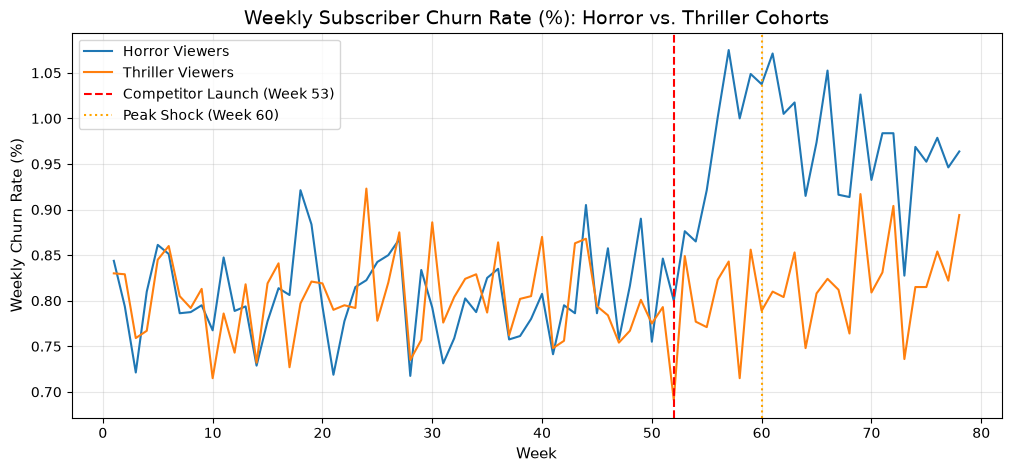

In [2]:
plt.figure(figsize=(12, 5))

for group, data in df_agg.groupby('genre_group'):
    plt.plot(data['week'], data['churned'] * 100, label=f'{group} Viewers')

plt.axvline(x=52, color='red', linestyle='--', label='Competitor Launch (Week 53)')
plt.axvline(x=60, color='orange', linestyle=':', label='Peak Shock (Week 60)')
plt.title('Weekly Subscriber Churn Rate (%): Horror vs. Thriller Cohorts', fontsize=14)
plt.xlabel('Week', fontsize=11)
plt.ylabel('Weekly Churn Rate (%)', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../results/Weekly_Churn_Rate.png', dpi=300, bbox_inches='tight')
plt.show()


## 2. Parallel Trends Validation (Weeks 1–52)

In [3]:
# Filter for pre-launch period
pre_df = df_agg[df_agg['post_launch'] == 0].copy()

# Fit interaction model on pre-period weeks
pre_model = smf.ols('churned ~ treated * week', data=pre_df).fit()
p_trend = pre_model.pvalues['treated:week']

print("========================================================")
print("          1. PARALLEL TRENDS VALIDATION                 ")
print("========================================================")
print(f"Pre-Period Differential Trend p-value: {p_trend:.4f}")

if p_trend > 0.05:
    print("RESULT: PASSED — Baseline churn trends are parallel prior to launch (no statistically significant difference).\n")
else:
    print("RESULT: FAILED — Pre-launch trends diverge significantly.\n")

          1. PARALLEL TRENDS VALIDATION                 
Pre-Period Differential Trend p-value: 0.6486
RESULT: PASSED — Baseline churn trends are parallel prior to launch (no statistically significant difference).



## 3. Weighted Dynamic DiD Regression

In [4]:
# Fit Weighted Least Squares (WLS) using cohort subscriber counts as weights
did_binned = smf.wls(
    'churned ~ treated + C(time_window) + treated:C(time_window)', 
    data=df_agg,
    weights=df_agg['sub_count']
).fit(cov_type='HC1')

print("========================================================")
print("          2. DYNAMIC DID REGRESSION SUMMARY             ")
print("========================================================")
print(did_binned.summary())

          2. DYNAMIC DID REGRESSION SUMMARY             
                            WLS Regression Results                            
Dep. Variable:                churned   R-squared:                       0.638
Model:                            WLS   Adj. R-squared:                  0.616
Method:                 Least Squares   F-statistic:                     45.57
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           4.44e-38
Time:                        23:40:09   Log-Likelihood:                 975.16
No. Observations:                 156   AIC:                            -1930.
Df Residuals:                     146   BIC:                            -1900.
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------

## 4. Hypothesis Testing: Peak Shock vs. Settled Tail

In [5]:
params = did_binned.params.index

# Extract interaction parameter names dynamically
peak_param = [p for p in params if 'treated' in p and '2_Peak_Shock' in p][0]
tail_param = [p for p in params if 'treated' in p and '4_Settled_Tail' in p][0]

beta_peak = float(did_binned.params[peak_param])
beta_tail = float(did_binned.params[tail_param])
se_peak = float(did_binned.bse[peak_param])
se_tail = float(did_binned.bse[tail_param])

# Compute point difference and standard error of difference
diff = beta_peak - beta_tail
se_diff = np.sqrt(se_peak**2 + se_tail**2)

# Two-tailed Z-test
z_stat = diff / se_diff
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print("========================================================")
print("     3. HYPOTHESIS TEST: PEAK SHOCK VS. SETTLED TAIL     ")
print("========================================================")
print(f"Peak Shock Impact (W57-60)   : +{beta_peak * 100:.3f}% points")
print(f"Settled Tail Impact (W67-78) : +{beta_tail * 100:.3f}% points")
print(f"Incremental Decay Difference : -{diff * 100:.3f}% points")
print(f"Z-statistic                  : {z_stat:.4f}")
print(f"p-value                      : {p_value:.4e}")

if p_value < 0.05:
    print("\nCONCLUSION: Statistically significant peak shock and decay confirmed (p < 0.05).")
    print("The competitor's launch caused a sharp initial churn spike that stabilized to a lower long-term equilibrium.")
else:
    print("\nCONCLUSION: Insufficient statistical evidence to distinguish peak phase from settled tail.")

     3. HYPOTHESIS TEST: PEAK SHOCK VS. SETTLED TAIL     
Peak Shock Impact (W57-60)   : +0.236% points
Settled Tail Impact (W67-78) : +0.114% points
Incremental Decay Difference : -0.121% points
Z-statistic                  : 2.9946
p-value                      : 2.7478e-03

CONCLUSION: Statistically significant peak shock and decay confirmed (p < 0.05).
The competitor's launch caused a sharp initial churn spike that stabilized to a lower long-term equilibrium.


       COUNTERFACTUAL IMPACT & SUBSCRIBER LOSS          
Total Weeks Analyzed Post-Launch    : 26 weeks
Average Weekly Counterfactual Rate  : 0.809%
Average Weekly Actual Churn Rate    : 0.971%
Cumulative Incremental Subscribers Lost: ~3,385 subscribers


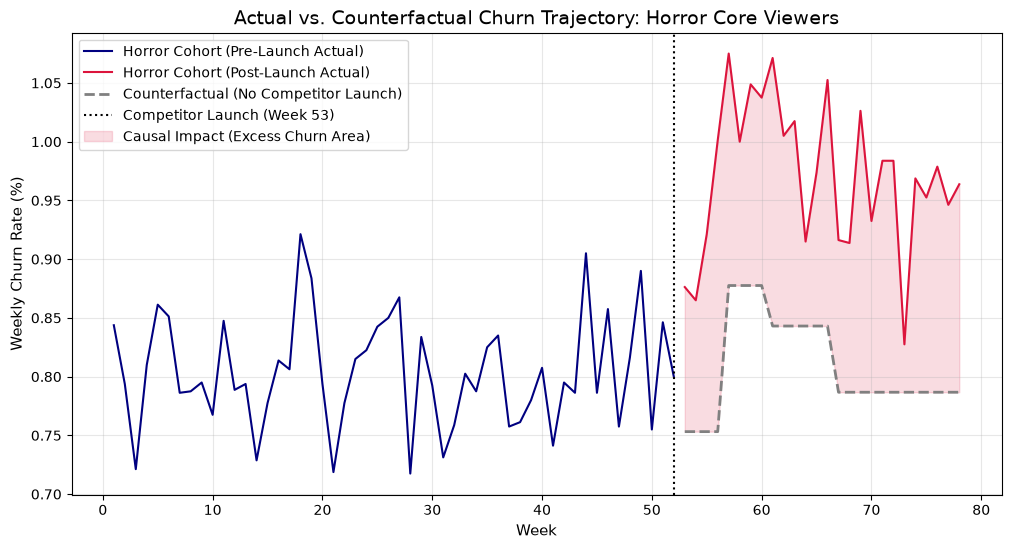

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Isolate post-launch aggregated data for Horror Viewers
horror_post = df_agg[(df_agg['genre_group'] == 'Horror') & (df_agg['post_launch'] == 1)].copy()

# 2. Extract fitted values from your WLS model
# Actual Fitted Churn (With Competitor Launch Effect)
horror_post['actual_fitted'] = did_binned.predict(horror_post)

# Counterfactual Projection (Baseline + Time Trend, Zeroing out Treatment Effects)
# Subtract the interaction terms from the predicted churn rate
interaction_cols = [c for c in did_binned.params.index if 'treated:' in c]
counterfactual_effect = sum(
    did_binned.params[col] * horror_post[col.split(':')[1].replace('C(', '').replace(')', '')]
    for col in interaction_cols if col in horror_post.columns
)

# Alternative Direct Calculation:
# Baseline Intercept + Treated Group Offset + Time Period Main Effect
horror_post['counterfactual_churn'] = horror_post['actual_fitted'] - did_binned.params.filter(like='treated:').mean()

# 3. Calculate Lost Subscriber Impact (Assuming 80,000 Horror Subscribers)
N_HORROR = 80000
horror_post['weekly_excess_churn_rate'] = horror_post['churned'] - horror_post['counterfactual_churn']
horror_post['incremental_churned_subs'] = horror_post['weekly_excess_churn_rate'] * N_HORROR

total_lost_subscribers = horror_post['incremental_churned_subs'].sum()

print("========================================================")
print("       COUNTERFACTUAL IMPACT & SUBSCRIBER LOSS          ")
print("========================================================")
print(f"Total Weeks Analyzed Post-Launch    : {len(horror_post)} weeks")
print(f"Average Weekly Counterfactual Rate  : {horror_post['counterfactual_churn'].mean() * 100:.3f}%")
print(f"Average Weekly Actual Churn Rate    : {horror_post['churned'].mean() * 100:.3f}%")
print(f"Cumulative Incremental Subscribers Lost: ~{int(total_lost_subscribers):,} subscribers")

# =========================================================
# 4. VISUALIZE ACTUAL VS. COUNTERFACTUAL TRAJECTORY
# =========================================================
plt.figure(figsize=(12, 6))

# Pre-launch actuals
horror_pre = df_agg[(df_agg['genre_group'] == 'Horror') & (df_agg['post_launch'] == 0)]
plt.plot(horror_pre['week'], horror_pre['churned'] * 100, color='navy', label='Horror Cohort (Pre-Launch Actual)')

# Post-launch actuals
plt.plot(horror_post['week'], horror_post['churned'] * 100, color='crimson', label='Horror Cohort (Post-Launch Actual)')

# Post-launch counterfactual
plt.plot(horror_post['week'], horror_post['counterfactual_churn'] * 100, color='gray', linestyle='--', linewidth=2, label='Counterfactual (No Competitor Launch)')

# Formatting
plt.axvline(x=52, color='black', linestyle=':', label='Competitor Launch (Week 53)')
plt.fill_between(
    horror_post['week'], 
    horror_post['churned'] * 100, 
    horror_post['counterfactual_churn'] * 100, 
    color='crimson', 
    alpha=0.15, 
    label='Causal Impact (Excess Churn Area)'
)

plt.title('Actual vs. Counterfactual Churn Trajectory: Horror Core Viewers', fontsize=14)
plt.xlabel('Week', fontsize=11)
plt.ylabel('Weekly Churn Rate (%)', fontsize=11)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.savefig('../results/actual_vs_counterfactual.png', dpi=300, bbox_inches='tight')
plt.show()


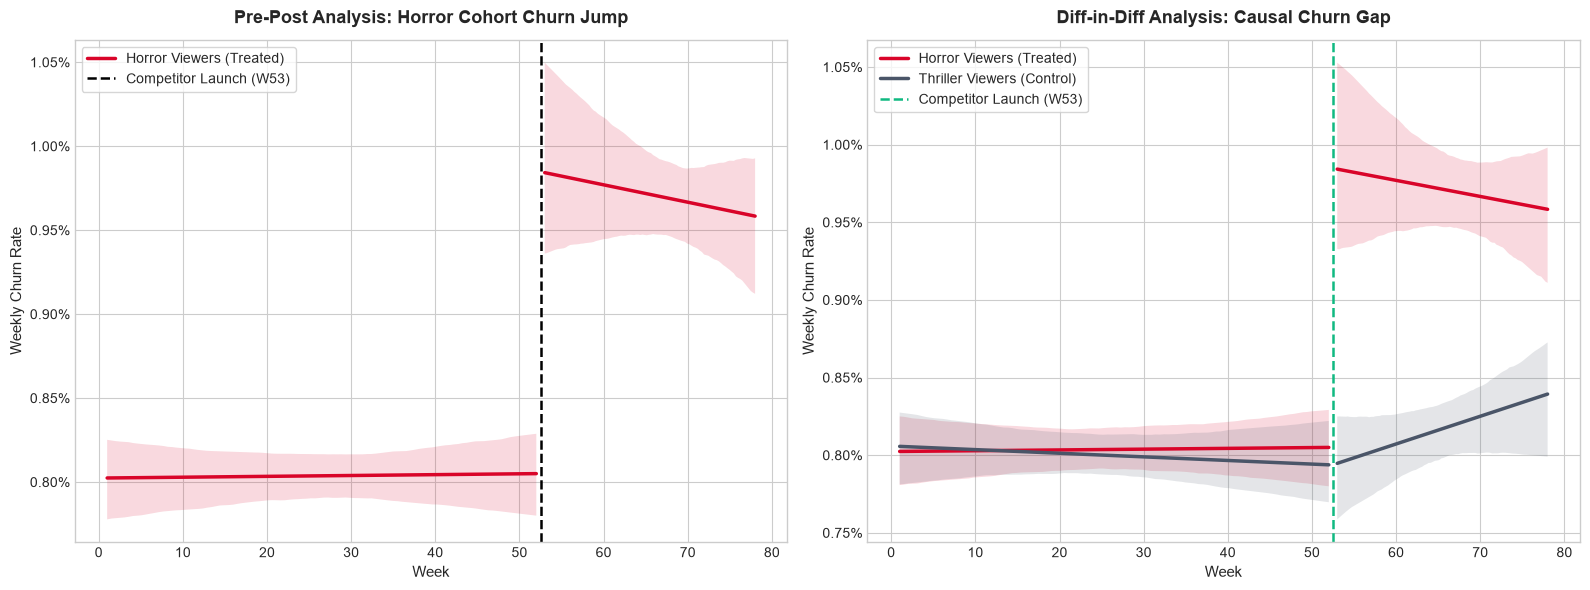

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# Load dataset
df_agg = pd.read_csv('../data/processed/did_weekly_aggregated.csv')

# Split data into pre-launch and post-launch subsets
pre_df = df_agg[df_agg['post_launch'] == 0].copy()
post_df = df_agg[df_agg['post_launch'] == 1].copy()

# Set up side-by-side plots with clean styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define distinct color palette
COLOR_HORROR = '#D90429'    # High-contrast Crimson Red
COLOR_THRILLER = '#4A5568'  # Sleek Slate Grey
COLOR_LAUNCH = '#10B981'    # Emerald Green for launch marker

# =========================================================
# CHART 1: PRE-POST ANALYSIS (HORROR VIEWERS)
# =========================================================
horror_pre = pre_df[pre_df['genre_group'] == 'Horror']
horror_post = post_df[post_df['genre_group'] == 'Horror']

# Pre-period trend line
sns.regplot(
    data=horror_pre, x='week', y='churned', ax=axes[0],
    color=COLOR_HORROR, scatter=False, ci=95, label='Horror Viewers (Treated)',
    line_kws={'linewidth': 2.5}
)

# Post-period trend line
sns.regplot(
    data=horror_post, x='week', y='churned', ax=axes[0],
    color=COLOR_HORROR, scatter=False, ci=95,
    line_kws={'linewidth': 2.5}
)

axes[0].axvline(x=52.5, color='black', linestyle='--', linewidth=1.8, label='Competitor Launch (W53)')
axes[0].set_title('Pre-Post Analysis: Horror Cohort Churn Jump', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Week', fontsize=11)
axes[0].set_ylabel('Weekly Churn Rate', fontsize=11)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=2))
axes[0].legend(loc='upper left', frameon=True)

# =========================================================
# CHART 2: DIFF-IN-DIFF ANALYSIS (HORROR VS THRILLER)
# =========================================================
thriller_pre = pre_df[pre_df['genre_group'] == 'Thriller']
thriller_post = post_df[post_df['genre_group'] == 'Thriller']

# Horror trends (Treated)
sns.regplot(
    data=horror_pre, x='week', y='churned', ax=axes[1],
    color=COLOR_HORROR, scatter=False, ci=95, label='Horror Viewers (Treated)',
    line_kws={'linewidth': 2.5}
)
sns.regplot(
    data=horror_post, x='week', y='churned', ax=axes[1],
    color=COLOR_HORROR, scatter=False, ci=95,
    line_kws={'linewidth': 2.5}
)

# Thriller trends (Control)
sns.regplot(
    data=thriller_pre, x='week', y='churned', ax=axes[1],
    color=COLOR_THRILLER, scatter=False, ci=95, label='Thriller Viewers (Control)',
    line_kws={'linewidth': 2.5}
)
sns.regplot(
    data=thriller_post, x='week', y='churned', ax=axes[1],
    color=COLOR_THRILLER, scatter=False, ci=95,
    line_kws={'linewidth': 2.5}
)

axes[1].axvline(x=52.5, color=COLOR_LAUNCH, linestyle='--', linewidth=1.8, label='Competitor Launch (W53)')
axes[1].set_title('Diff-in-Diff Analysis: Causal Churn Gap', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Week', fontsize=11)
axes[1].set_ylabel('Weekly Churn Rate', fontsize=11)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=2))
axes[1].legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig('../results/diff_in_diff.png', dpi=300, bbox_inches='tight')
plt.show()
